# Customer Churn Prediction Model

## Importing Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

## Importing Dataset And Basic Knowledge of Dataset

In [3]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')

In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [5]:
df.shape

(440833, 12)

In [6]:
df.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
296314,303428.0,46.0,Male,19.0,24.0,4.0,5.0,Standard,Annual,950.40,2.0,0.0
124894,128911.0,49.0,Female,37.0,30.0,6.0,14.0,Basic,Quarterly,928.00,3.0,1.0
157871,162682.0,43.0,Female,35.0,8.0,6.0,24.0,Basic,Annual,203.00,10.0,1.0
396459,403574.0,49.0,Female,39.0,23.0,0.0,0.0,Premium,Quarterly,889.52,4.0,0.0
329932,337047.0,43.0,Male,25.0,27.0,0.0,2.0,Basic,Quarterly,686.67,18.0,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [8]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [9]:
# Handling Missing Values

df = df.dropna()

## EDA

### 1. Target Variable: Churn Distribution

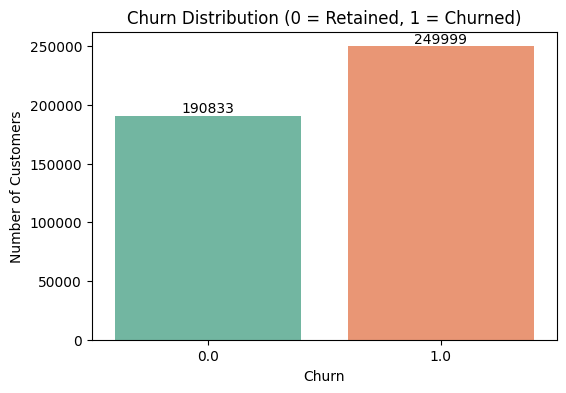

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64
Churn
1.0    56.7
0.0    43.3
Name: proportion, dtype: float64 %


In [10]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution (0 = Retained, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, '%')

**Observation:** The target classes are reasonably balanced (no extreme skew), so accuracy alone should be a fine metric, but it's still good practice to check precision/recall/F1 per class when modeling.

### 2. Numerical Feature Distributions

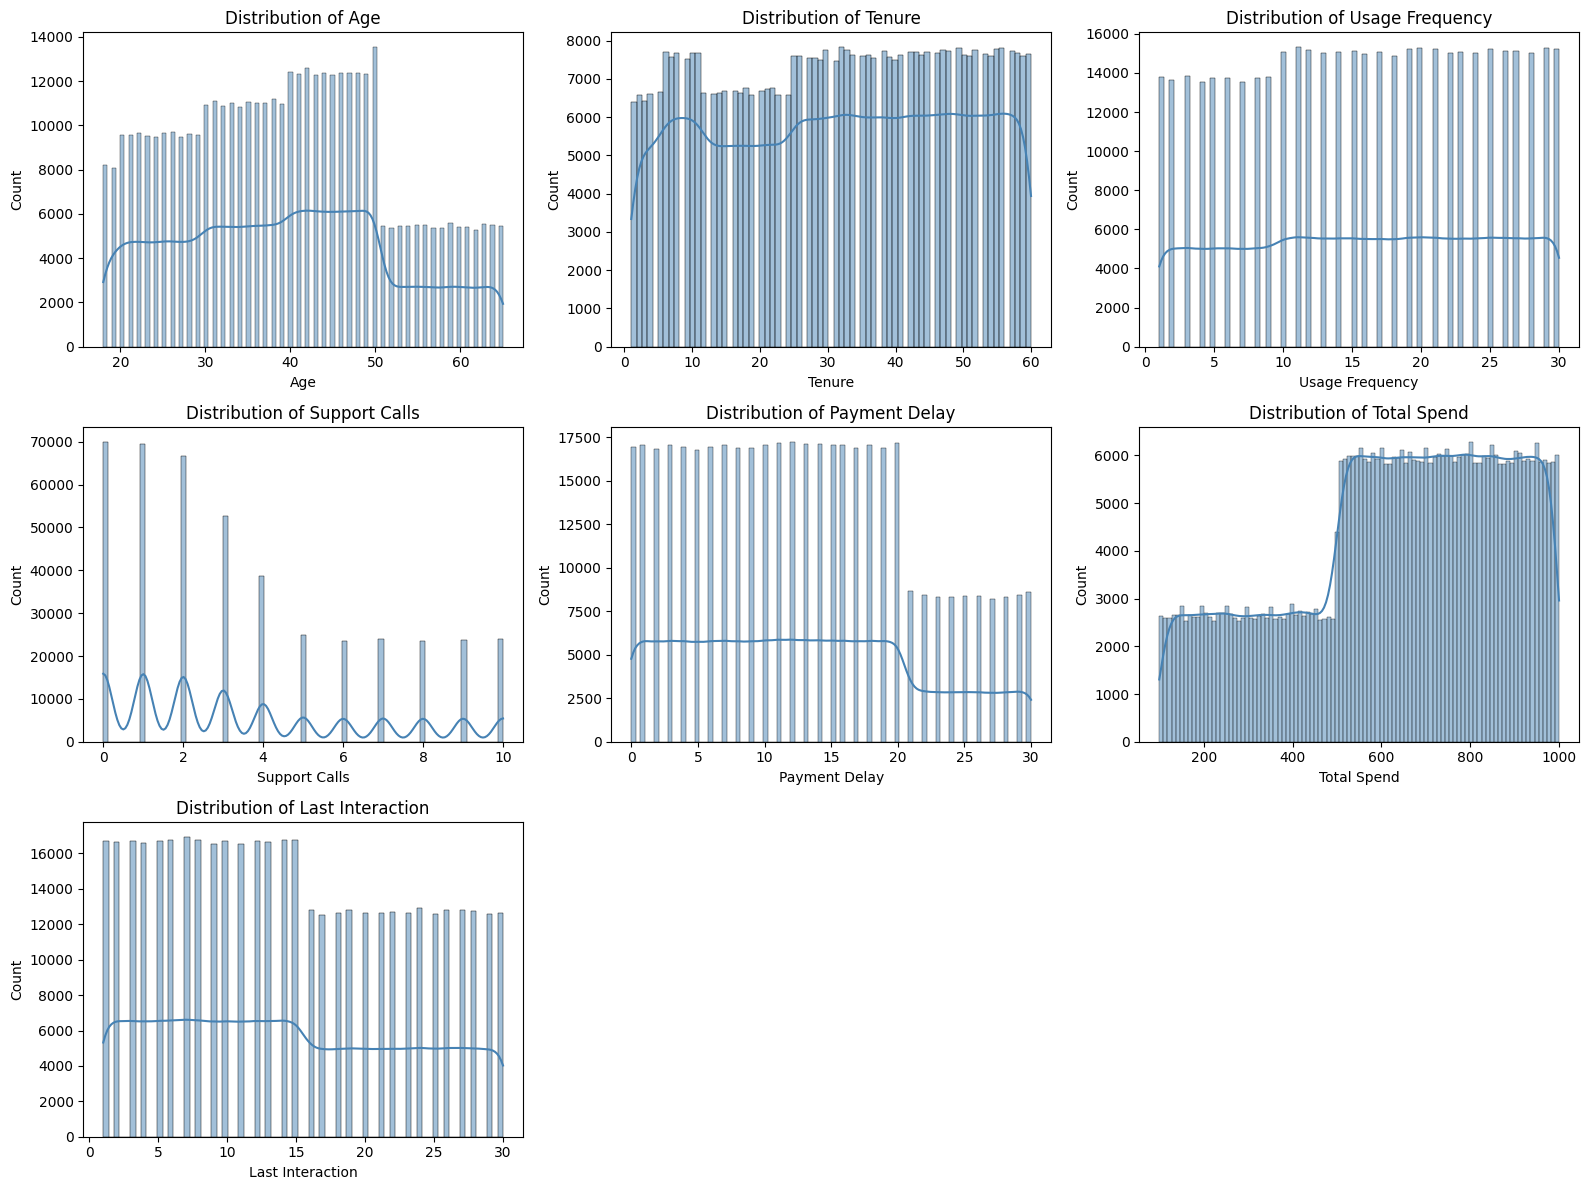

In [11]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### 3. Numerical Features vs Churn

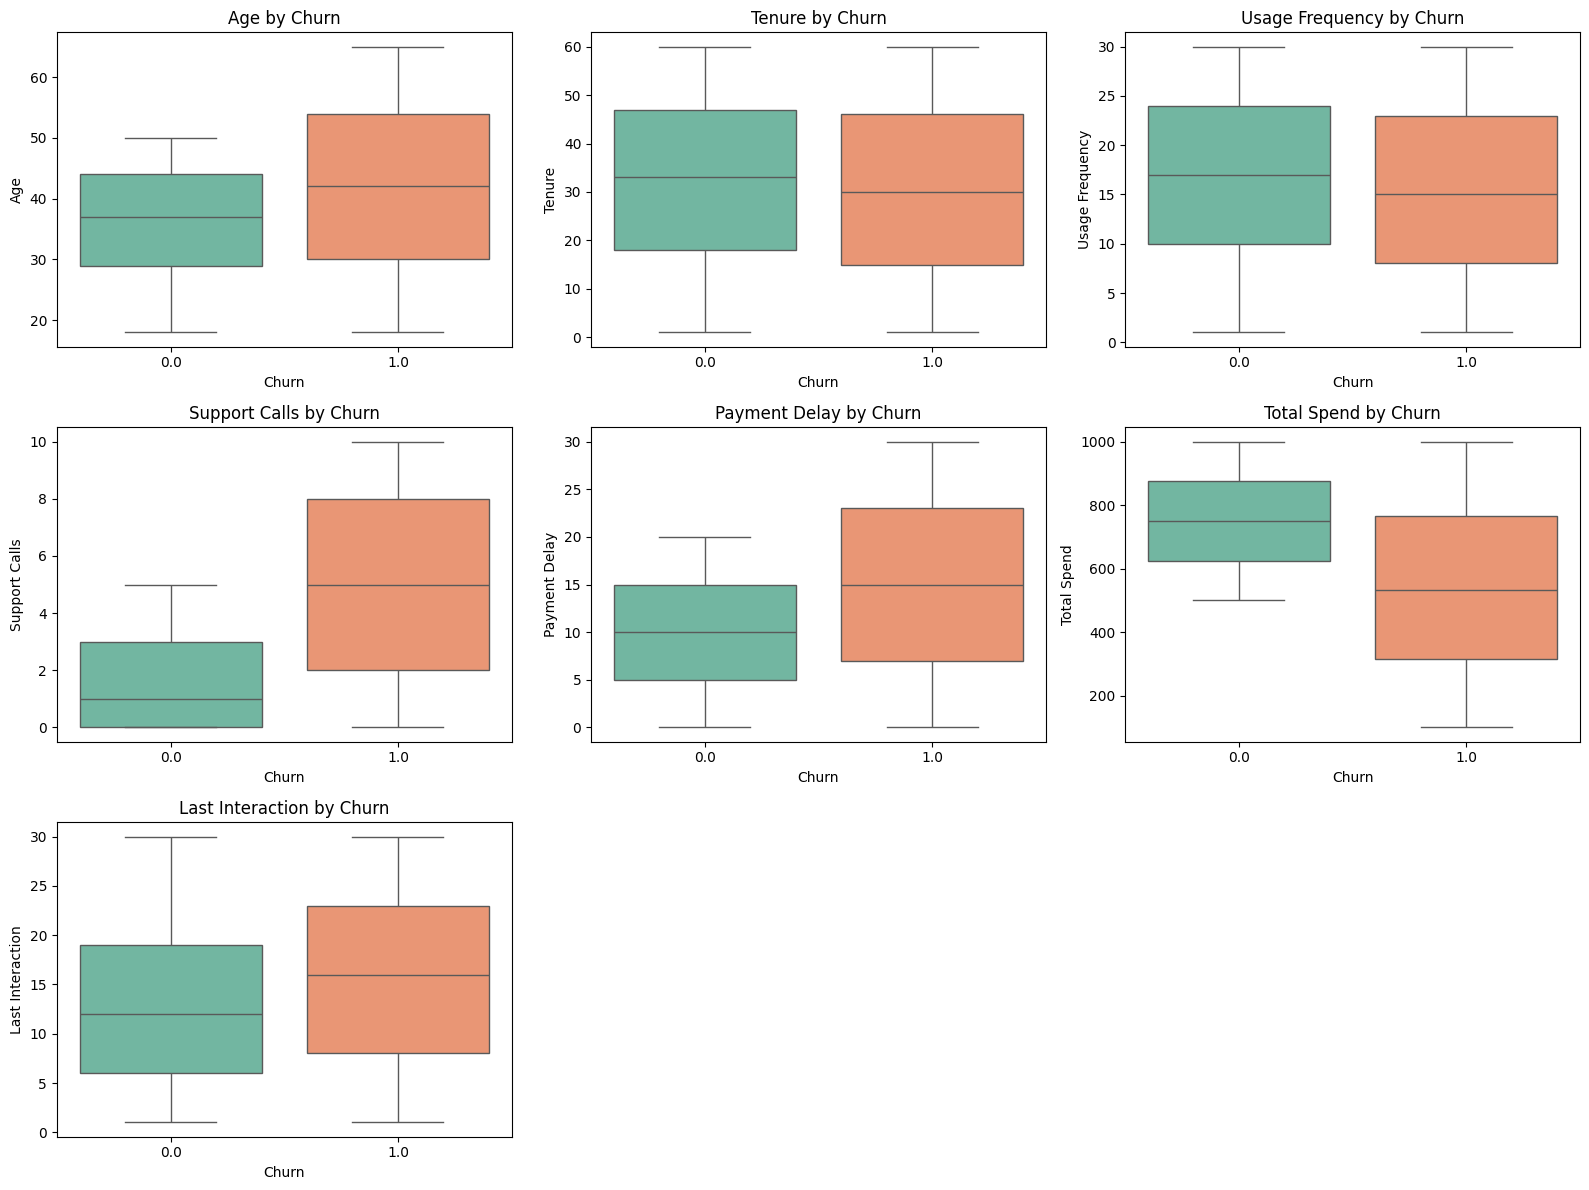

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Churn')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Observation:** Look for features where the churned vs retained boxes are clearly shifted apart (e.g. Support Calls, Payment Delay often separate well in churn datasets) — these tend to be the strongest predictors.

### 4. Categorical Features

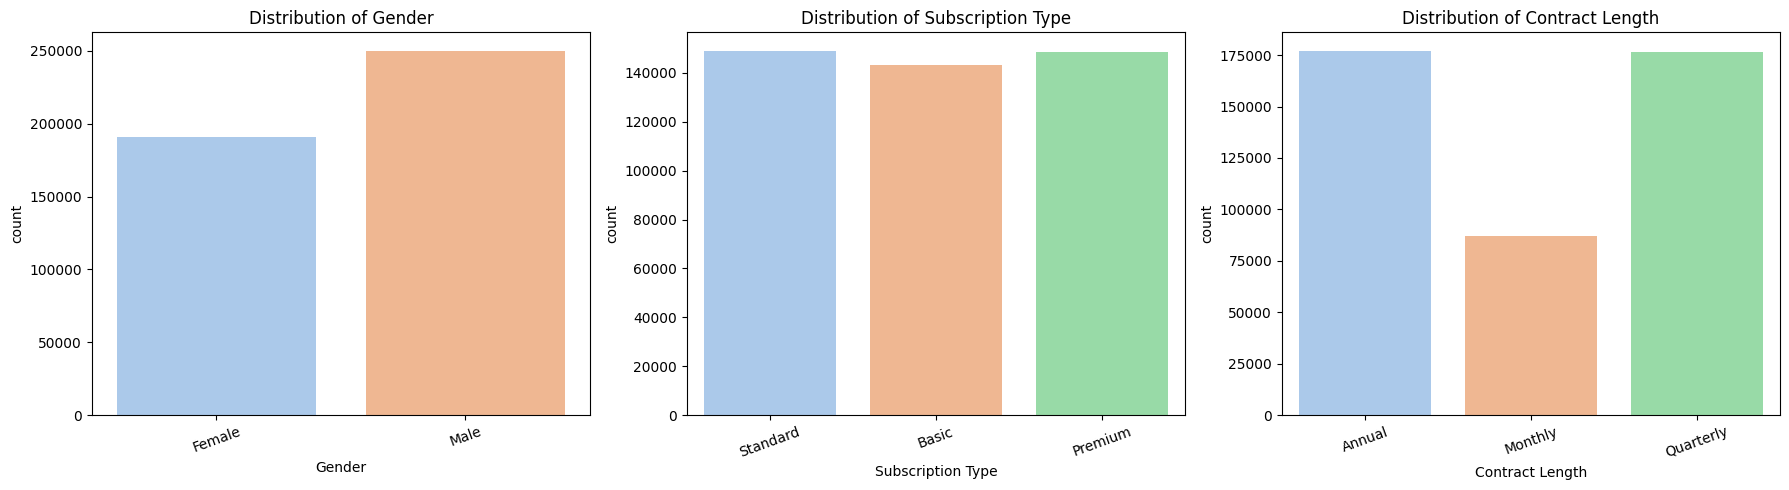

In [13]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 5. Categorical Features vs Churn (Churn Rate %)

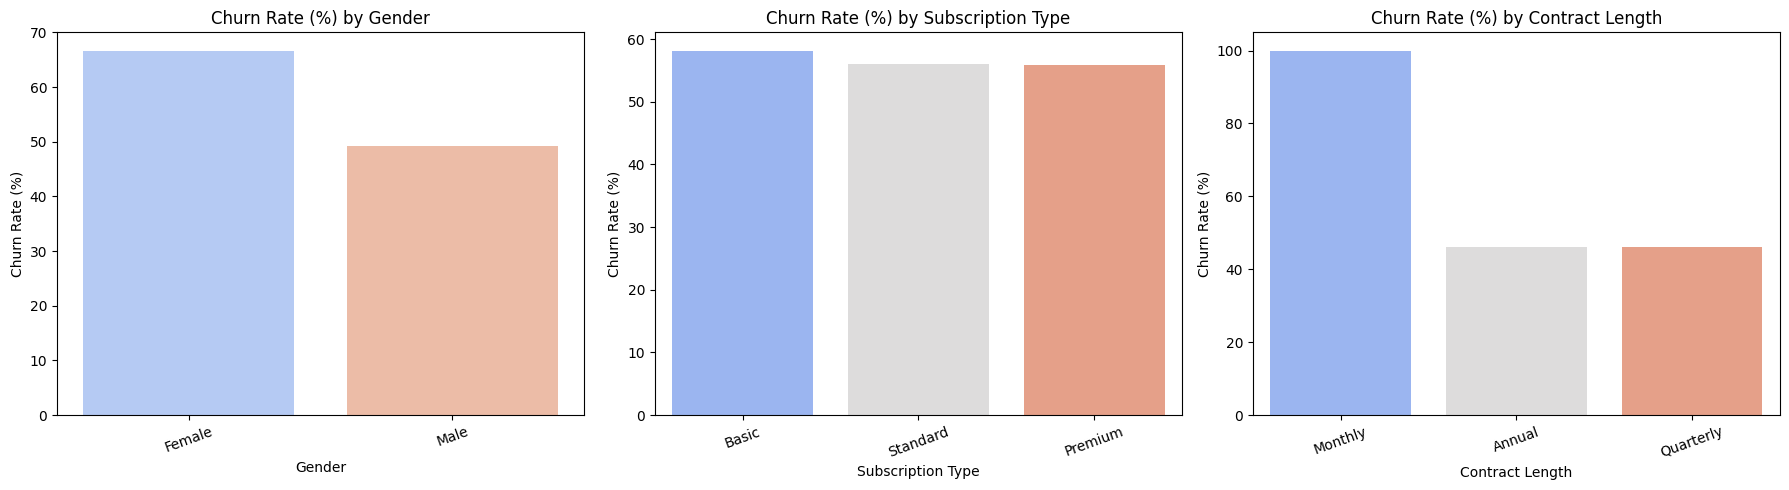

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Churn Rate (%) by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Observation:** Compare churn rate bars across categories — a noticeably taller bar for, say, 'Monthly' contracts vs 'Annual' would suggest contract length is a strong churn driver.

### 6. Correlation Heatmap (Numerical Features)

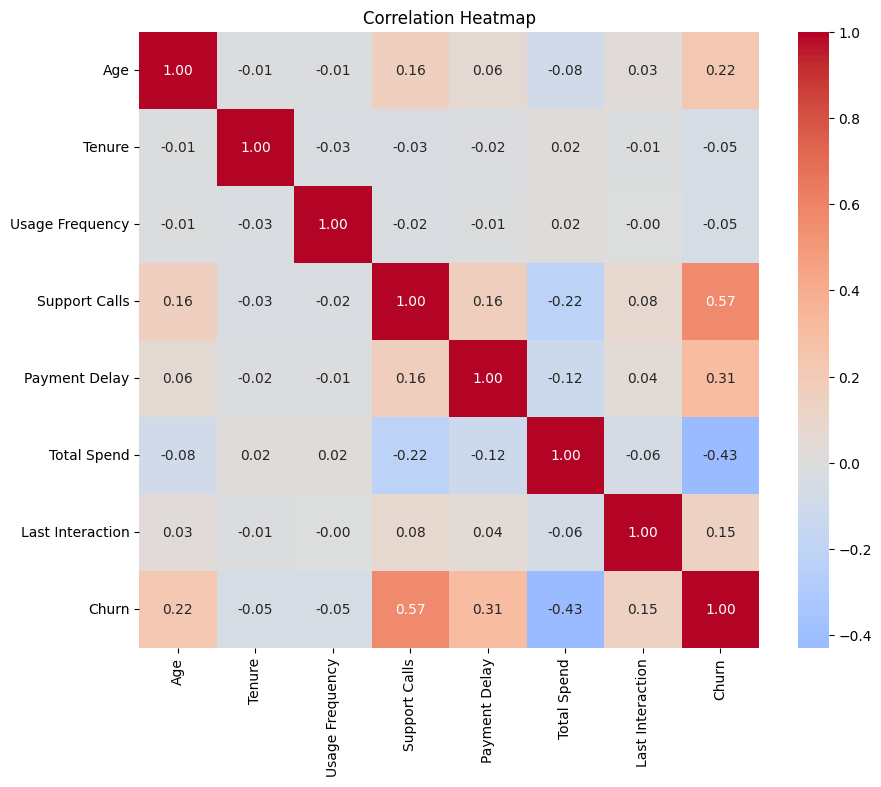

In [15]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### 7. Total Spend vs Age (colored by Churn)

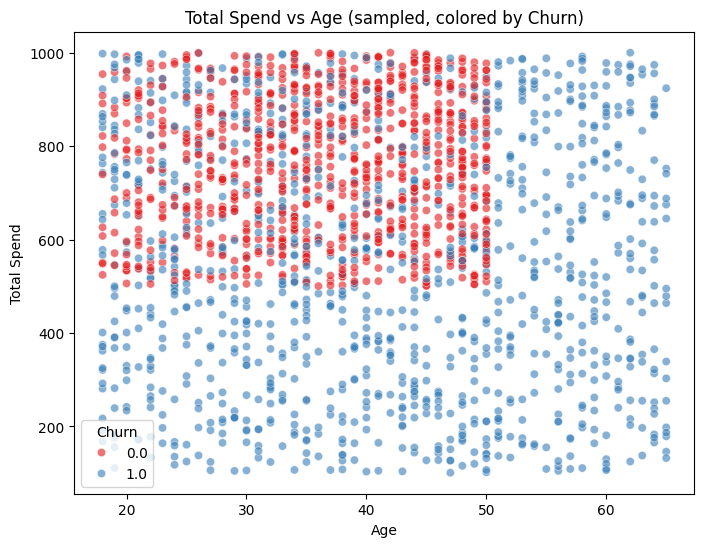

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Total Spend', hue='Churn', data=df.sample(2000, random_state=42),
                alpha=0.6, palette='Set1')
plt.title('Total Spend vs Age (sampled, colored by Churn)')
plt.show()

### 8. Outlier Check (Total Spend & Tenure)

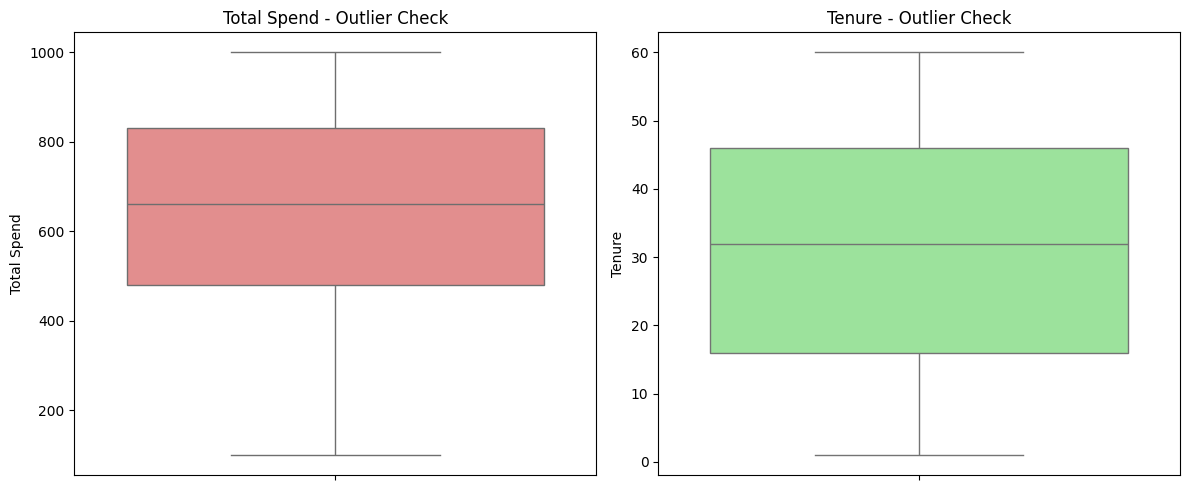

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Total Spend'], ax=axes[0], color='lightcoral')
axes[0].set_title('Total Spend - Outlier Check')
sns.boxplot(y=df['Tenure'], ax=axes[1], color='lightgreen')
axes[1].set_title('Tenure - Outlier Check')
plt.tight_layout()
plt.show()

### 9. EDA Summary
- **Target balance:** Churn classes are not extremely imbalanced — good for standard classification metrics.
- **Key numeric drivers to watch:** Support Calls, Payment Delay, Total Spend, Tenure — check the boxplots above for clear separation between churned/retained groups.
- **Key categorical drivers to watch:** Contract Length and Subscription Type — compare churn-rate bars above.
- **Correlation:** Use the heatmap to spot multicollinearity between numeric features before modeling.
- **Next steps:** Encode categorical variables (Gender, Subscription Type, Contract Length), scale numeric features if needed, then proceed to train/test split and modeling (Logistic Regression / Decision Tree / Random Forest, as already imported above).